- data 폴더 안에 bodyPerformance.csv 파일을 로드 
- 데이터 중 dtype가 object인 데이터는 LabelEncoding 사용
- 독립, 종속 변수 데이터 분할 
- train, test, 8:2 비율로 분할 
- 독립 데이터들은 StandardScaler를 이용하여 스케일링
- Target의 Class의 개수만큼 Linear 모델에서 아웃풋 출력을 설정하는 모델을 생성 
- 손실함수는 CrossEntropy 사용
- optimizer는 Adam 사용
- 최종 예측 값을 이용하여 성능 평가 

In [10]:
import pandas as pd 
import torch 
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [11]:
df = pd.read_csv("../data/bodyPerformance.csv")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [13]:
obj_cols = df.select_dtypes('object').columns
le = LabelEncoder()
for col in obj_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
x = df.drop('class', axis=1)
y = df['class']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
# 모델 정의 
class body_clf(nn.Module):
    def __init__(self, _dim):
        super(body_clf, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim*3),        # 직선을 그려준다.
            nn.ReLU(),                      # 직선을 33개의 꺽은선으로 변경 
            nn.Linear(_dim*3, _dim*2),      
            nn.ReLU(),                      # 33개의 직선을 각각 22개씩으로 꺽어준다
            nn.Linear(_dim*2, 4),
        )
    def forward(self, x):
        return self.model(x)

In [20]:
# 모델 생성 
body_model = body_clf(X_train_tensor.shape[1])

In [21]:
criterion = nn.CrossEntropyLoss()
# Adam() : 학습율 lr과 관성 momentum을 자동으로 조절한다.  // Adam에서 lr은 학습율의 최대 값을 제한
optimizer = optim.Adam(body_model.parameters(), lr=0.001)

In [22]:
body_model.train()
for epoch in range(200):
    pred = body_model(X_train_tensor)
    loss = criterion(pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {round(loss.item(), 6)}")

Epoch 20, Loss: 1.325559
Epoch 40, Loss: 1.221961
Epoch 60, Loss: 1.091598
Epoch 80, Loss: 0.988443
Epoch 100, Loss: 0.919904
Epoch 120, Loss: 0.877431
Epoch 140, Loss: 0.853861
Epoch 160, Loss: 0.83951
Epoch 180, Loss: 0.829264
Epoch 200, Loss: 0.821225


In [24]:
body_model.eval()
with torch.no_grad():
    pred = body_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    acc = accuracy_score(y_test_tensor, pred_idx)
    print(f"Test Accuracy: {round(acc, 4)}")
    print(classification_report(y_test_tensor, pred_idx))

Test Accuracy: 0.6342
              precision    recall  f1-score   support

           0       0.66      0.78      0.71       670
           1       0.49      0.46      0.47       669
           2       0.57      0.54      0.55       670
           3       0.82      0.76      0.79       670

    accuracy                           0.63      2679
   macro avg       0.63      0.63      0.63      2679
weighted avg       0.63      0.63      0.63      2679



In [25]:
import matplotlib.pyplot as plt

In [43]:
# 선형 모델 
linear_model = nn.Sequential(
    nn.Linear(1, 64), 
    nn.Linear(64, 1)
)

In [44]:
# 비선형 모델 
relu_model = nn.Sequential(
    nn.Linear(1, 64), 
    nn.ReLU(), 
    nn.Linear(64, 1)
)

In [45]:
loss = nn.MSELoss()
optimizer_linear = optim.Adam(linear_model.parameters(), lr=0.01)
optimizer_relu = optim.Adam(relu_model.parameters(), lr=0.01)

In [46]:
# sin 데이터 생성 
x = torch.linspace(-3, 3, 200).unsqueeze(1)  # (200, 1)
y = torch.sin(x)

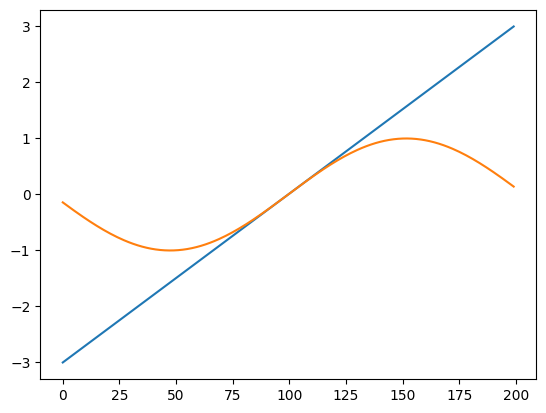

In [47]:
plt.plot(x)
plt.plot(y)
plt.show()

In [48]:
#  반복 학습 
for epoch in range(3000):
    # 선형 모델의 학습
    pred1 = linear_model(x)
    loss1 = loss(pred1, y)
    optimizer_linear.zero_grad()
    loss1.backward()
    optimizer_linear.step()
    # 비선형 모델의 학습
    pred2 = relu_model(x)
    loss2 = loss(pred2, y)
    optimizer_relu.zero_grad()
    loss2.backward()
    optimizer_relu.step()

In [49]:
# 예측 결과 
# detach() : 예측의 결과는 결과값 + 가중치 함수 데이터가 포함되어있기 때문에 detach()로 결과값만 가져온다.
linear_pred = linear_model(x).detach()
relu_pred = relu_model(x).detach()
print(linear_pred)

tensor([[-1.0236],
        [-1.0133],
        [-1.0030],
        [-0.9927],
        [-0.9825],
        [-0.9722],
        [-0.9619],
        [-0.9516],
        [-0.9413],
        [-0.9310],
        [-0.9207],
        [-0.9104],
        [-0.9002],
        [-0.8899],
        [-0.8796],
        [-0.8693],
        [-0.8590],
        [-0.8487],
        [-0.8384],
        [-0.8281],
        [-0.8179],
        [-0.8076],
        [-0.7973],
        [-0.7870],
        [-0.7767],
        [-0.7664],
        [-0.7561],
        [-0.7458],
        [-0.7356],
        [-0.7253],
        [-0.7150],
        [-0.7047],
        [-0.6944],
        [-0.6841],
        [-0.6738],
        [-0.6635],
        [-0.6533],
        [-0.6430],
        [-0.6327],
        [-0.6224],
        [-0.6121],
        [-0.6018],
        [-0.5915],
        [-0.5812],
        [-0.5710],
        [-0.5607],
        [-0.5504],
        [-0.5401],
        [-0.5298],
        [-0.5195],
        [-0.5092],
        [-0.4989],
        [-0.

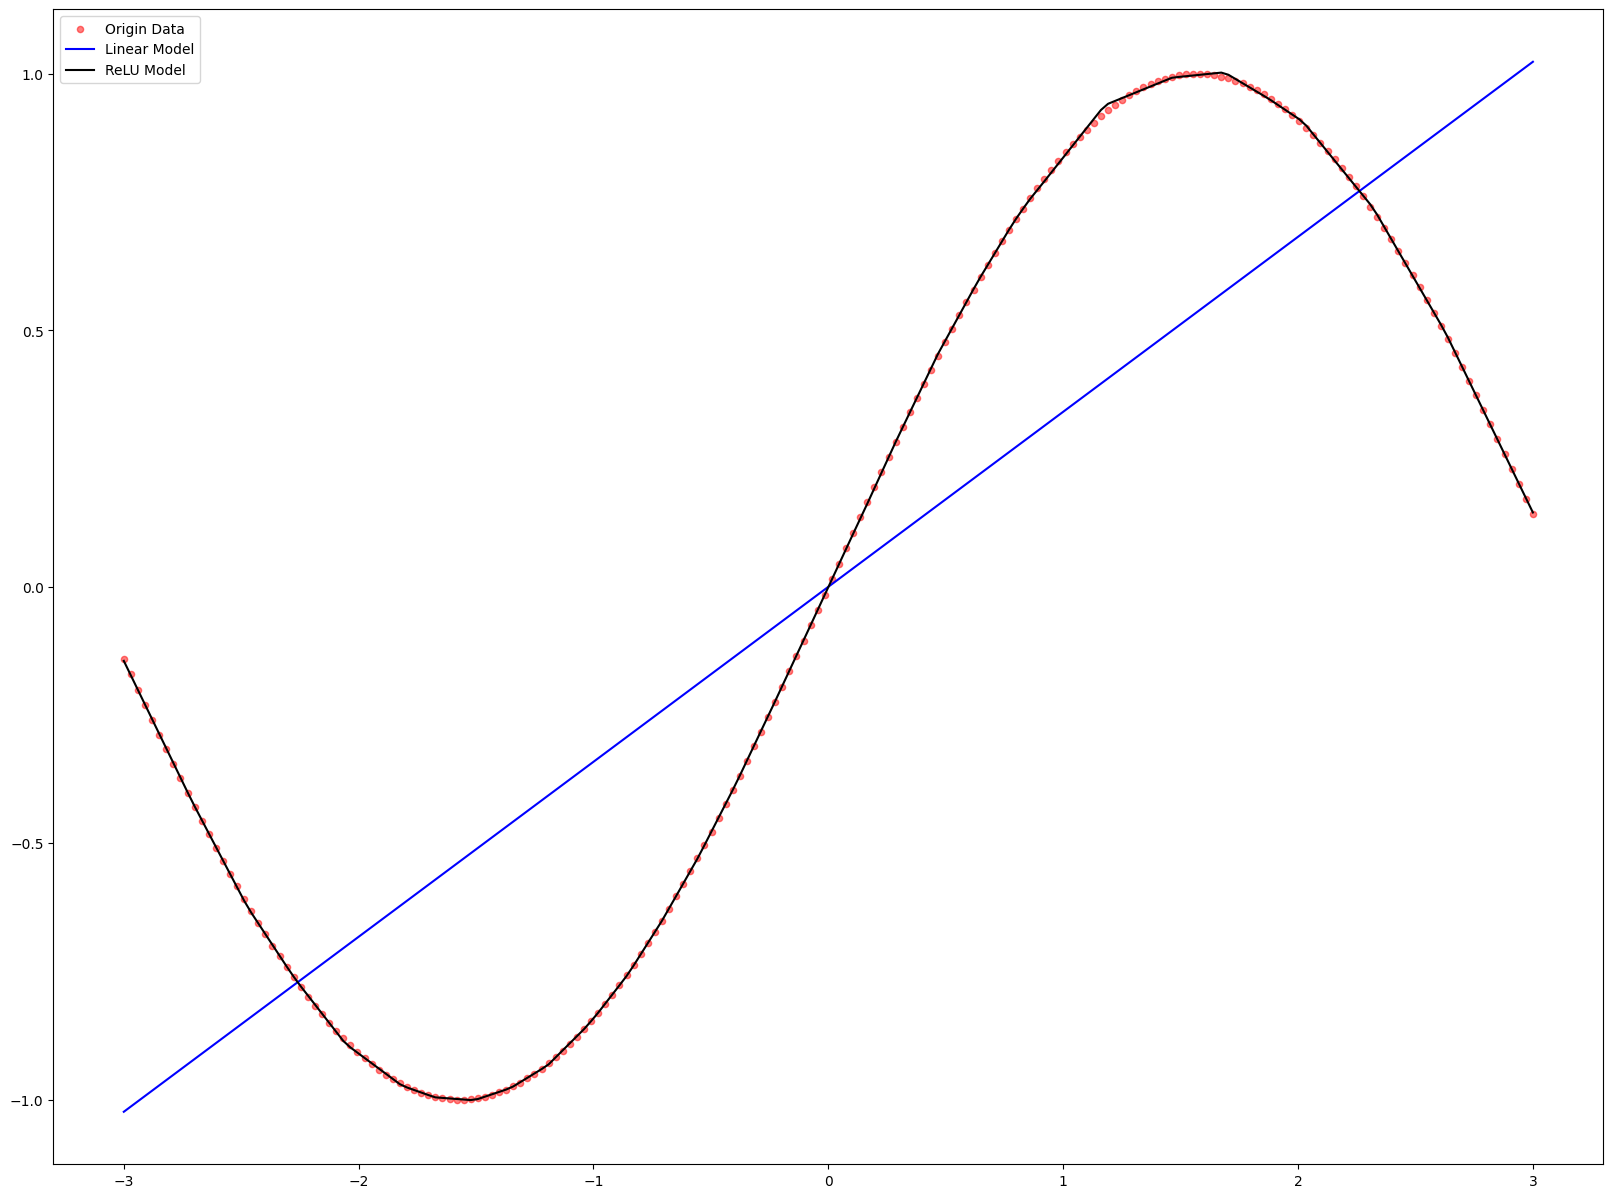

In [50]:
plt.figure(figsize=(20, 15))
# 원본 데이터 산점도 표시 
plt.scatter(x, y, label = 'Origin Data', s = 20, color = 'red', alpha = 0.5)
# 선형 모델 예측 결과를 라인 그래프로 표시 
plt.plot(x, linear_pred, label = 'Linear Model', color = 'blue')
# 비선형 모델의 예측 결과 라인 그래프로 표시 
plt.plot(x, relu_pred, label = 'ReLU Model', color = 'black')

plt.legend()

plt.show()